In [1]:
import pandas as pd
import numpy as np
import networkx as nx

from rdkit import Chem
import matplotlib.pyplot as plt
%matplotlib inline


from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
import torch_geometric.transforms as T

import torch
import torch.nn.functional as F
from torch.optim.lr_scheduler import MultiplicativeLR

from sklearn.metrics import roc_auc_score ,auc,precision_recall_curve

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from flashtext import KeywordProcessor

import re



/home/giobbi/DDI_LLM_repo/DDI_with_ML/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Process Data

## Graph Data

In [2]:
DDI_graph = pd.read_csv('https://raw.githubusercontent.com/liiniix/BioSNAP/master/ChCh-Miner/ChCh-Miner_durgbank-chem-chem.tsv', sep='\t')
DDI_graph.rename(columns={'Drug1': 'src', 'Drug2': 'dst'}, inplace=True)
DrugIDs_in_graph = np.unique(DDI_graph.values) # there are 1514 unique drugs in the graph

G = nx.from_pandas_edgelist(DDI_graph, 'src', 'dst')

## SMILES Data


In [3]:
drugsSMILES = pd.read_csv('https://raw.githubusercontent.com/sshaghayeghs/molSMILES/main/structure%20links%202.csv')
drugID_smiles = drugsSMILES[["DrugBank ID", "SMILES"]]
drugID_smiles.dropna(inplace=True)
drugID_smiles.reset_index(drop=True, inplace=True)

/tmp/ipykernel_518258/706743108.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drugID_smiles.dropna(inplace=True)


## Description Data

In [4]:
drugsDESC = pd.read_csv('https://raw.githubusercontent.com/sshaghayeghs/molSMILES/main/Drug_description.csv')
drugID_DESC = drugsDESC[["Drug ID", "Discription"]]
drugID_DESC.dropna(inplace=True)
drugID_DESC.reset_index(drop=True, inplace=True)

/tmp/ipykernel_518258/1344816557.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drugID_DESC.dropna(inplace=True)


## Description Embeddings

In [5]:
# Load embeddings (assuming first column is DrugBank ID)
embeddings_df = pd.read_csv('/data/giobbi/embeddings/Dr_Desc_GPT.csv', sep='\t', index_col=0)
if 'Unnamed: 0' in embeddings_df.columns:
    embeddings_df = embeddings_df.drop(columns='Unnamed: 0')

# Filter to drugs in your graph (optional, if not already done)
embeddings_df = embeddings_df[embeddings_df.iloc[:, 0].isin(DrugIDs_in_graph)].reset_index(drop=True)



# Sync Datasets

In [6]:
#checking if a molecule has a valid molecule corespodn to the smiles string
def is_valid_molecule(smiles) -> bool:
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

In [7]:
valid_smiles = pd.DataFrame(drugID_smiles)
valid_smiles['IsValidMolecule'] = drugID_smiles['SMILES'].apply(is_valid_molecule)
df_valid_molecules = valid_smiles[valid_smiles['IsValidMolecule']]

# Drop the temporary 'IsValidMolecule' column
df_valid_molecules = df_valid_molecules.drop(columns=['IsValidMolecule'])

[12:29:57] Explicit valence for atom # 13 Cl, 5, is greater than permitted
[12:29:57] SMILES Parse Error: syntax error while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[12:29:57] SMILES Parse Error: check for mistakes around position 84:
[12:29:57] C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O
[12:29:57] ~~~~~~~~~~~~~~~~~~~~^
[12:29:57] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[12:29:57] SMILES Parse Error: check for mistakes around position 40:
[12:29:57] 1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2
[12:29:57] ~~~~~~~~~~~~~~~~~~~~^
[12:29:57] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C

In [8]:

allowed_drug=[list(df_valid_molecules['DrugBank ID']),list(drugID_DESC['Drug ID'])]
# There are 1278 drugIDs that occur in the graph. Some graph nodes do not have associated SMILES or drug description

#droping the links that do not have any SMILES
for l in allowed_drug:
  for index, row in DDI_graph.iterrows():
      # Check if both cells in the row are in the allowed cells list
      if row['src'] not in l or row['dst'] not in l:
          #b If either cell is not in the allowed cells list, remove the row
          DDI_graph.drop(index, inplace=True)



In [9]:
#27800 edges
DDI_graph=DDI_graph.reset_index(drop=True)


In [10]:
#save the drugs smiles and drug description in the networks into a new dataframe
drugID_smiles_ddi = drugID_smiles[drugID_smiles['DrugBank ID'].isin(list(np.unique(DDI_graph.values)))]
drugID_smiles_ddi=drugID_smiles_ddi.reset_index(drop=True)
drugID_DESC_ddi = drugID_DESC[drugID_DESC['Drug ID'].isin(list(np.unique(DDI_graph.values)))]
drugID_DESC_ddi=drugID_DESC_ddi.reset_index(drop=True)

In [11]:
drugID_DESC_ddi = drugID_DESC_ddi.merge(
    embeddings_df,
    left_on='Drug ID',
    right_on=embeddings_df.columns[0],
    how='left',
    suffixes=('', '_emb')  # Add suffix to right columns
)

# Drop the right-side 'Discription_emb' column if it exists
if 'Discription_emb' in drugID_DESC_ddi.columns:
    drugID_DESC_ddi = drugID_DESC_ddi.drop(columns=['Discription_emb'])

drugID_DESC_ddi # 1323 drugs with description
drugID_smiles_ddi # 1323 drugs with smiles
DDI_graph # interaction graph with ? nodes and 41639 edges

# Analyze Drug Description

In [12]:
drugsDESC_masked = drugID_DESC_ddi.copy()
drug_list = drugsDESC['Drug Name'].to_list()
drug_ID_list = drugsDESC_masked['Drug ID'].to_list()

# Build processor
kp = KeywordProcessor(case_sensitive=False)
for drug in drug_list:
    kp.add_keyword(drug, "<DRUG>")
for drug_ID in drug_ID_list:
    kp.add_keyword(drug_ID, "<DRUG>")



# Replace & count
drugsDESC_masked['Description_Masked'] = drugsDESC_masked['Discription'].apply(kp.replace_keywords)
drugsDESC_masked['drug_count'] = drugsDESC_masked['Discription'].apply(
    lambda x: len(kp.extract_keywords(x))
)

drugsDESC_masked.sort_values(by='drug_count', ascending=False, inplace=True)

In [13]:
# pharma_class column

# Define keyword lists for each class
keyword_classes = {
    0: [  # Antidepressants
        "antidepressant", "tricyclic", "tca", "ssri", "snri", "maoi", "serotonin", "norepinephrine reuptake"
    ],
    1: [  # Antifungals
        "antifungal", "azole", "ergosterol", "ketoconazole", "fluconazole", "itraconazole", "voriconazole"
    ],
    2: [  # Antihypertensives
        "antihypertensive", "hypertension", "angiotensin ii receptor blocker", "arb",
        "ace inhibitor", "calcium channel blocker", "ccb", "beta-blocker"
    ],
    3: [  # Antibiotics
        "antibiotic", "macrolide", "penicillin", "cephalosporin", "fluoroquinolone", "tetracycline", "bacterial infections"
    ],
    4: [  # Antivirals
        "antiviral", "protease inhibitor", "reverse transcriptase inhibitor", "integrase inhibitor",
        "hiv", "hepatitis", "influenza"
    ],
    5: [  # Anticancer (chemotherapy / oncology)
        "antineoplastic", "chemotherapy", "kinase inhibitor", "monoclonal antibody", "cytotoxic"
    ],
    6: [  # Analgesics / Pain management
        "analgesic", "opioid", "nsaid", "pain"
    ],
    7: [  # Antidiabetics
        "antidiabetic", "insulin", "glp-1", "sglt2 inhibitor", "metformin"
    ],
    8: [  # Gastrointestinal / Acid-related
        "proton pump inhibitor", "ppi", "h2 receptor antagonist", "gerd", "ulcer"
    ]
}


def assign_class(description):
    if pd.isnull(description):
        return 9  # None of the keywords
    desc = description.lower()
    for class_idx, keywords in keyword_classes.items():
        for kw in keywords:
            # For "azole" match as word ending, otherwise substring
            if kw == "azole":
                if re.search(r"\w+azole\b", desc):
                    return class_idx
            elif kw in desc:
                return class_idx
    return 9  # None of the keywords

# Assign class integer to each row
drugsDESC_masked['pharma_class'] = drugsDESC_masked['Discription'].apply(assign_class)

# Optional: check class distribution
print(drugsDESC_masked['pharma_class'].value_counts())

pharma_class
9    721
2    149
3    107
6     90
0     64
5     63
4     49
1     47
8     17
7     16
Name: count, dtype: int64


In [14]:
drugsDESC_masked['pharma_class']

12      9
259     0
687     1
777     0
466     1
       ..
1087    9
1097    9
1056    6
169     9
171     5
Name: pharma_class, Length: 1323, dtype: int64

# Visualize Embedding

## Apply t-SNE for Dimensionality Reduction
Use sklearn.manifold.TSNE to reduce the embeddings to 2D or 3D.

In [15]:
from sklearn.manifold import TSNE

In [16]:
# shuffle for visualization purposes
drugsDESC_masked.dropna(inplace=True)
drug_embeddings = drugsDESC_masked.select_dtypes(include=['float64', 'int64'])

In [17]:
# Apply t-SNE for Dimensionality Reduction

# Initialize t-SNE with 2 components for 2D visualization
tsne = TSNE(n_components=2, random_state=42)

# Apply t-SNE to the drug embeddings
reduced_embeddings = tsne.fit_transform(drug_embeddings)

# Convert the reduced embeddings to a DataFrame for easier handling
reduced_embeddings_df = pd.DataFrame(reduced_embeddings, columns=['TSNE-1', 'TSNE-2'])


# Visualize t-SNE Results with Matplotlib
Plot the 2D t-SNE results using matplotlib's scatter plot.

In [18]:
import plotly.express as px

# Create an interactive scatter plot with Plotly
fig = px.scatter(
    reduced_embeddings_df,
    x='TSNE-1',
    y='TSNE-2',
    color=drugsDESC_masked['drug_count'],
    color_continuous_scale='Turbo',
    hover_data={
        'Drug Name': drugsDESC_masked.get('Drug Name', None),
        'Discription': drugsDESC_masked['Discription'],
        'drug_count': drugsDESC_masked['drug_count']
    },
    title='Interactive t-SNE Visualization of Drug Embeddings'
)

fig.update_layout(
    coloraxis_colorbar=dict(
        title='Drug Count in Description'
    ),
    width=900,
    height=700
)

fig.show()

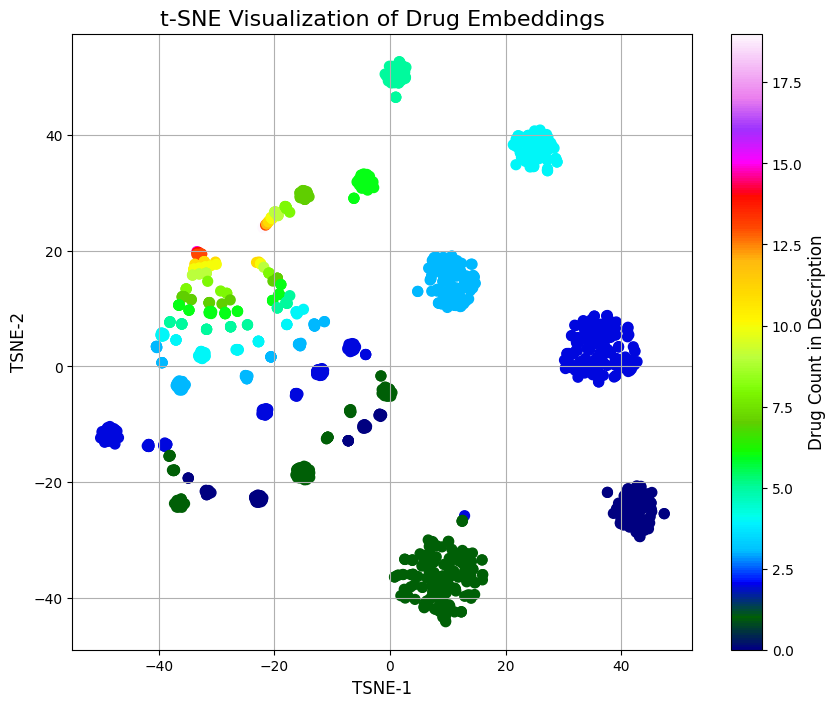

In [19]:
# Normalize the drug count for coloring
norm = plt.Normalize(drugsDESC_masked['drug_count'].min(), drugsDESC_masked['drug_count'].max())

color = drugsDESC_masked['drug_count']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    reduced_embeddings_df['TSNE-1'],
    reduced_embeddings_df['TSNE-2'],
    alpha=1, s=50,
    c=color,  # Pass the raw values here
    cmap='gist_ncar', #gist_ncar gist_rainbow
    norm=norm
)
plt.title('t-SNE Visualization of Drug Embeddings', fontsize=16)
plt.xlabel('TSNE-1', fontsize=12)
plt.ylabel('TSNE-2', fontsize=12)
plt.grid(True)

# Add a colorbar to show the drug_count scale
cbar = plt.colorbar(scatter)
cbar.set_label('Drug Count in Description', fontsize=12)

plt.show()

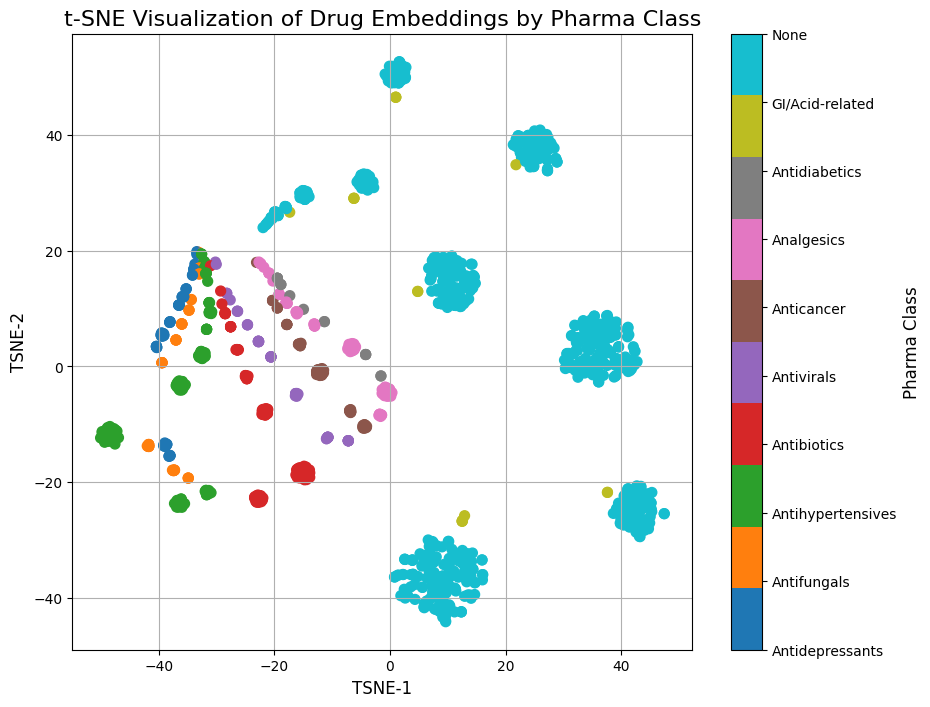

In [24]:
from matplotlib.colors import ListedColormap


# Ensure pharma_class is integer and fill NaNs with 9 (the 'None' class)
pharma_class = drugsDESC_masked['pharma_class'].fillna(9).astype(int)
cmap = ListedColormap(plt.get_cmap('tab10').colors[:10])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    reduced_embeddings_df['TSNE-1'],
    reduced_embeddings_df['TSNE-2'],
    alpha=1, s=50,
    c=pharma_class,
    cmap=cmap
)
plt.title('t-SNE Visualization of Drug Embeddings by Pharma Class', fontsize=16)
plt.xlabel('TSNE-1', fontsize=12)
plt.ylabel('TSNE-2', fontsize=12)
plt.grid(True)

# Add a colorbar with class labels
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.ax.set_yticklabels([
    'Antidepressants', 'Antifungals', 'Antihypertensives', 'Antibiotics', 'Antivirals',
    'Anticancer', 'Analgesics', 'Antidiabetics', 'GI/Acid-related', 'None'
])
cbar.set_label('Pharma Class', fontsize=12)

plt.show()